# Precedence Comparison Charts

Three views of the overlap-topic precedence computed in `density_comparison.ipynb`
(loaded from `overlap_precedence_full.tsv`). Each view is produced for **two
precedence criteria**:

- **First quartile (`delta_q1_years`)** — the standard view (filenames unchanged).
- **Earliest 5% (`delta_p5_years`)** — a stricter "leading edge" comparison that
  contrasts only the first 5% of project and paper years (`_p5` filenames).

The three views:

- **Option A — split violins**: full year distributions per corpus.
- **Option B — dumbbell**: papers vs teams median years with IQR bands.
- **Option C — diverging gap**: the precedence gap centred at zero.
- **Option D — pixel grid**: a grid/heatmap analogue of the split violins — two year-cell strips per topic (Papers blue, Teams orange), each coloured by its share of the topic's peak year.

> Run `compute_coords.ipynb` and `density_comparison.ipynb` first.

In [12]:
# ── Make the shared aux/ package importable ───────────────────────────────────
# These notebooks live in 05-reporting/ alongside the aux/ package.
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

from aux.paths import REPORTS_DIR, set_seed
from aux.coords import load_plot_data
from aux.precedence import gather_year_pools, plot_violin, plot_dumbbell, plot_diverging, plot_pixel_grid

set_seed()
df_papers, df_teams, XLIM, YLIM = load_plot_data()
df_prec = pd.read_csv(REPORTS_DIR / "overlap_precedence_full.tsv", sep="\t")
print(f"Loaded {len(df_prec)} overlap topics from overlap_precedence_full.tsv")

Loaded 64 overlap topics from overlap_precedence_full.tsv


## Option A — horizontal split violins

[q1] Topics plotted: 64


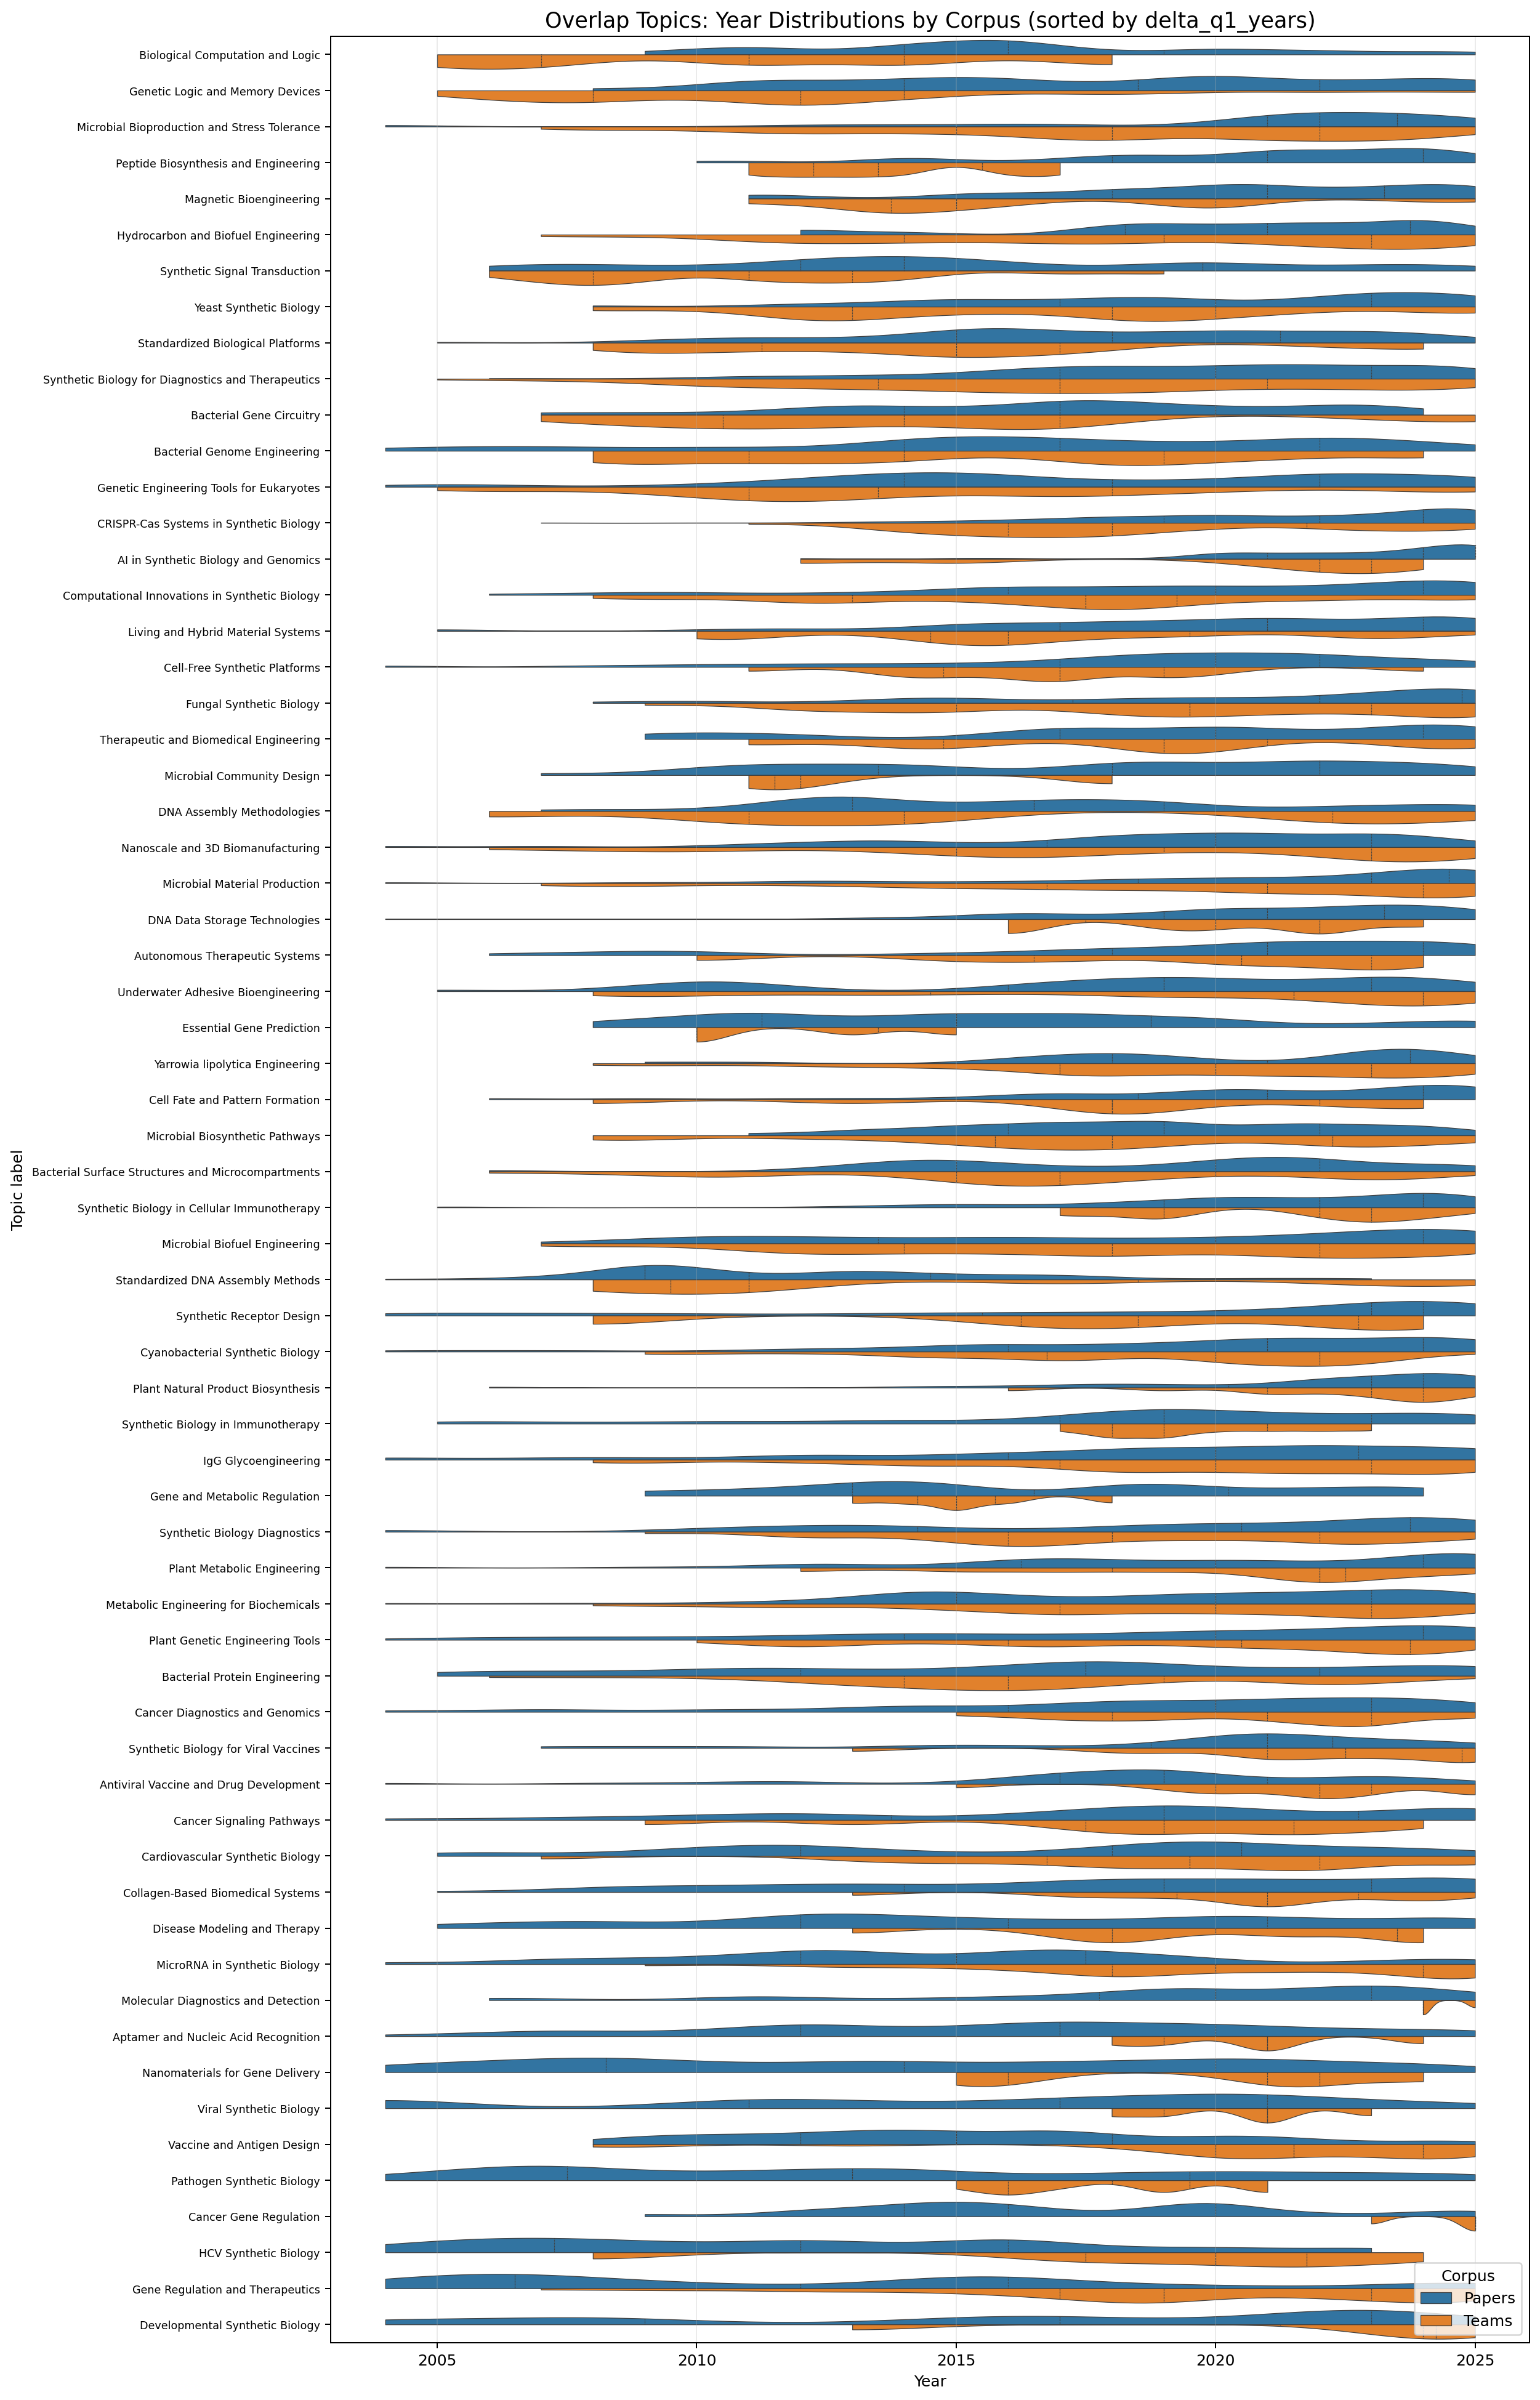

[p5] Topics plotted: 64


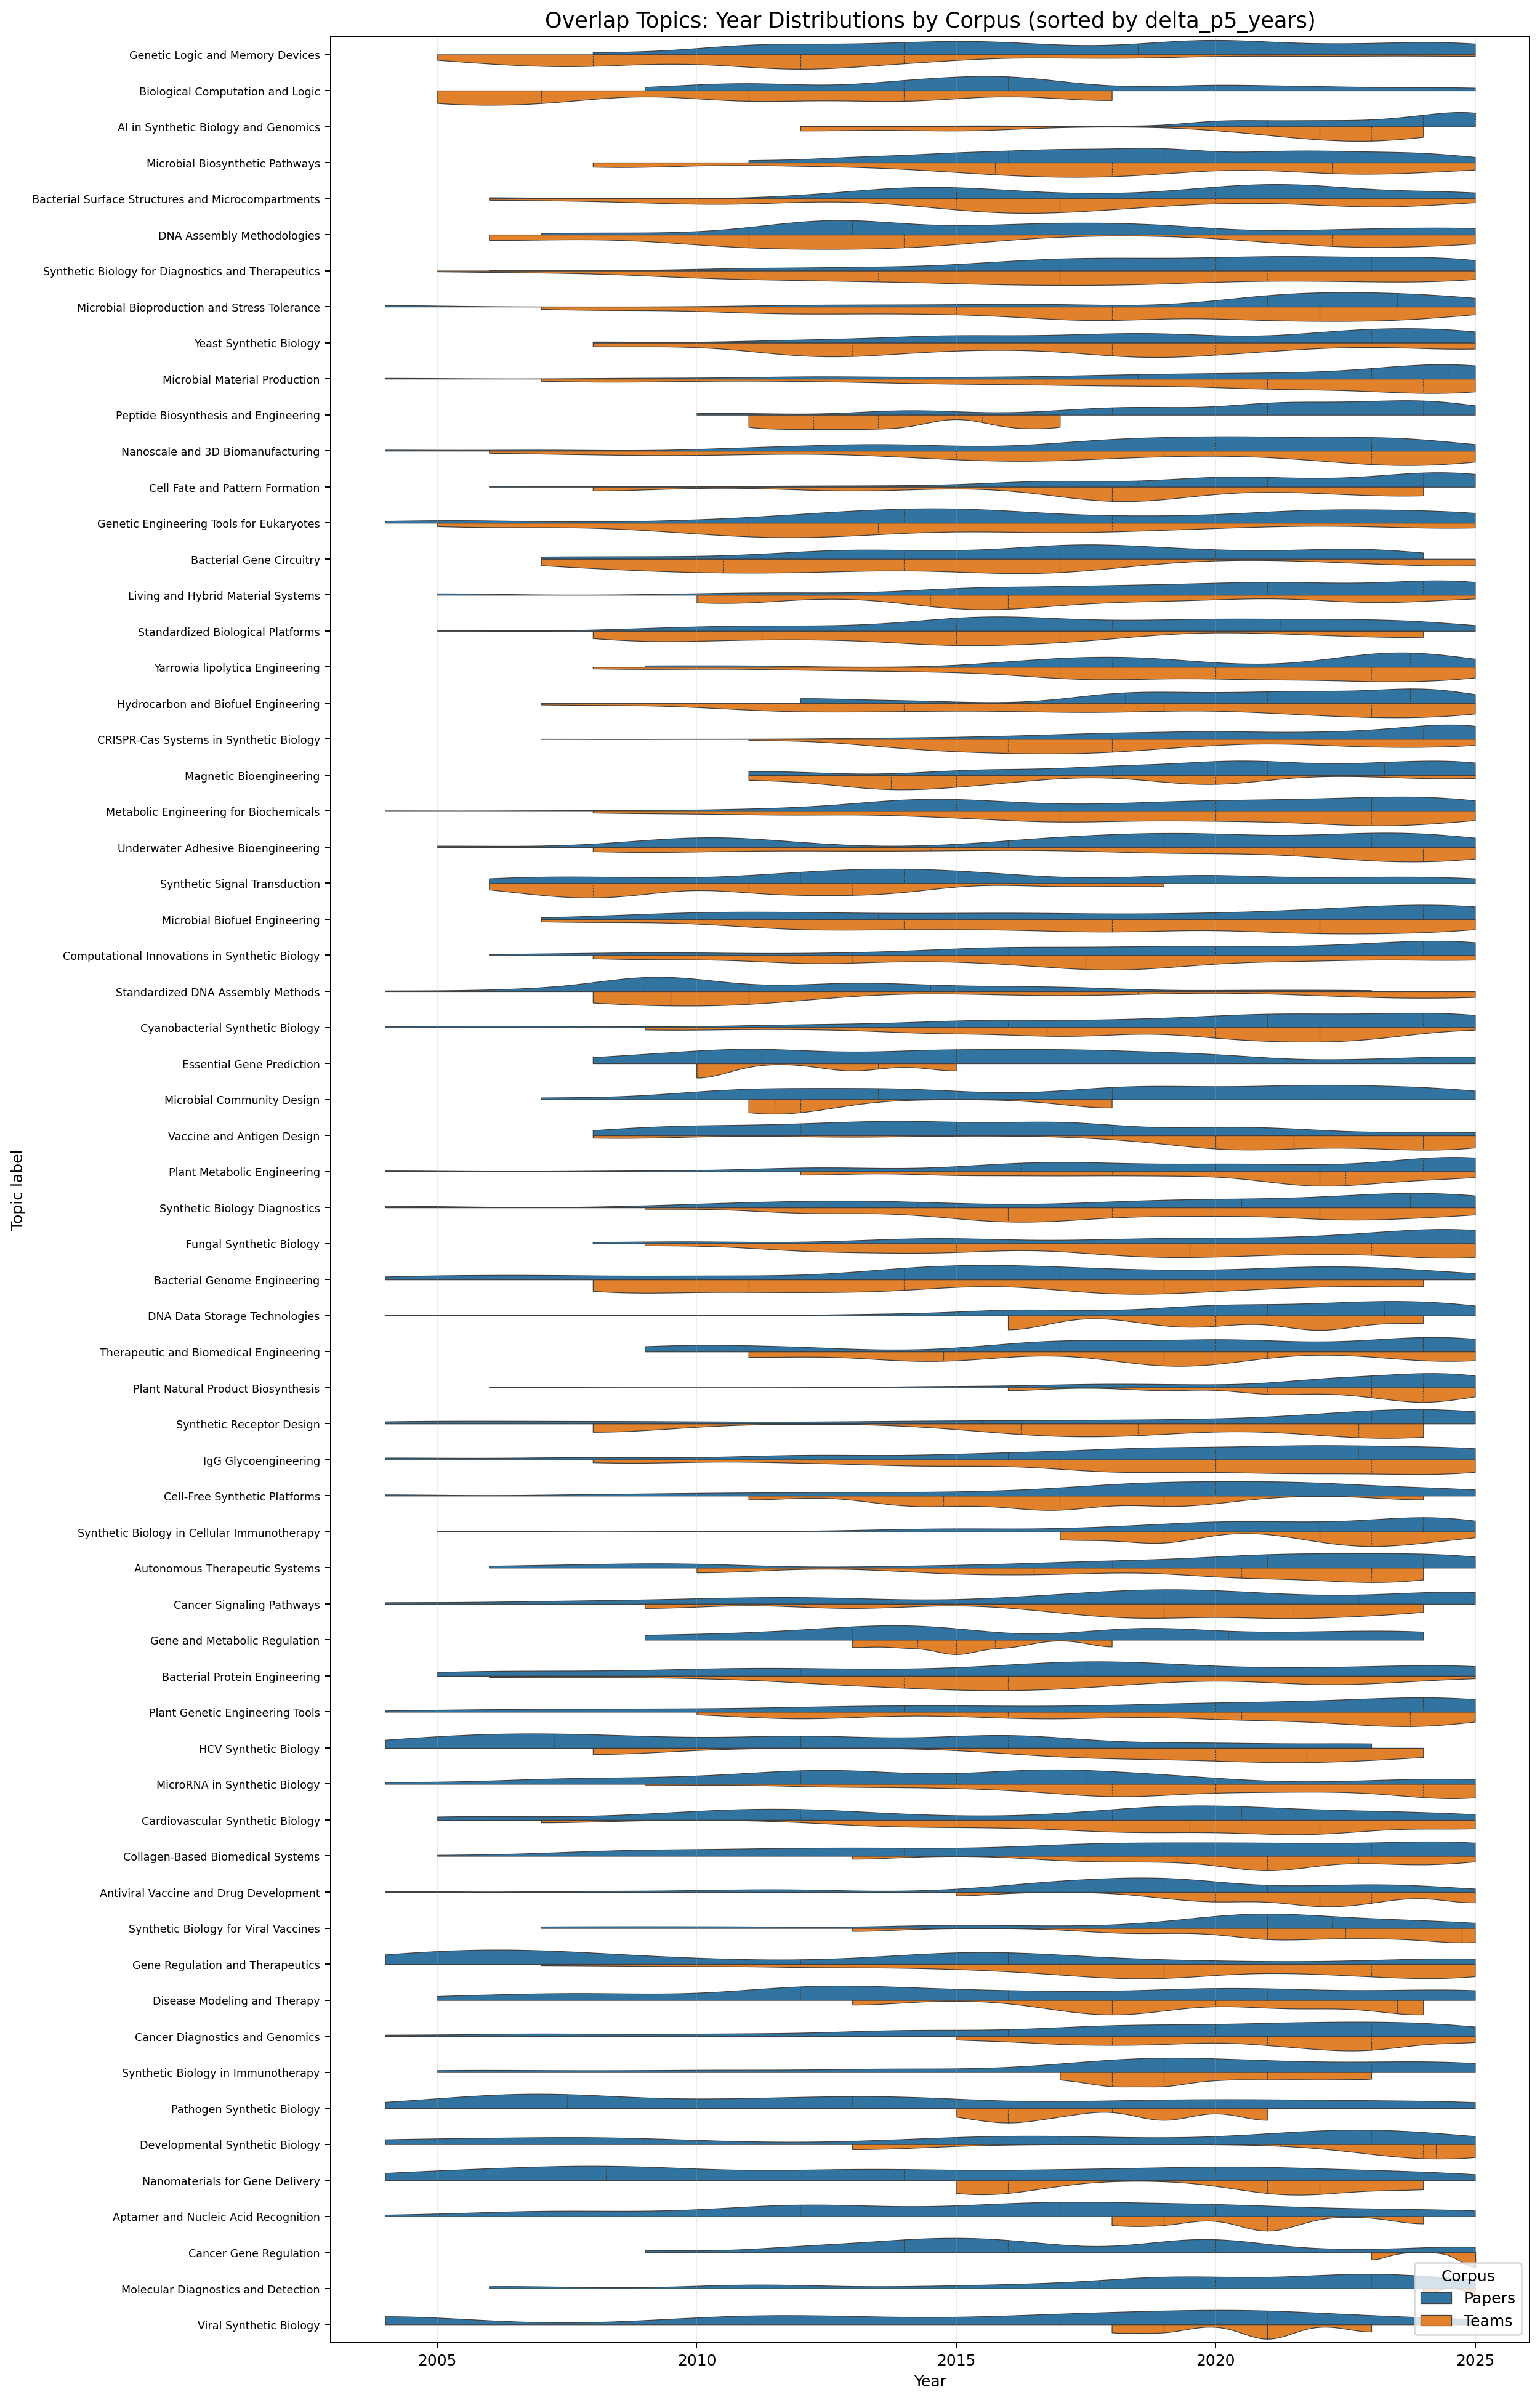

In [14]:
# Option A for both criteria: first quartile (delta_q1) and the stricter earliest 5% (delta_p5).
for stat, suffix in (("q1", ""), ("p5", "_p5")):
    pool, ordered = gather_year_pools(df_prec, df_papers, df_teams, stat=stat)
    print(f"[{stat}] Topics plotted: {pool['topic_label'].nunique() if not pool.empty else 0}")
    fig, _ = plot_violin(
        pool, ordered, stat=stat,
        out_path=REPORTS_DIR / f"overlap_precedence_violin_horizontal{suffix}.png",
    )
    plt.show()

## Option B — horizontal dumbbell (median years + IQR)

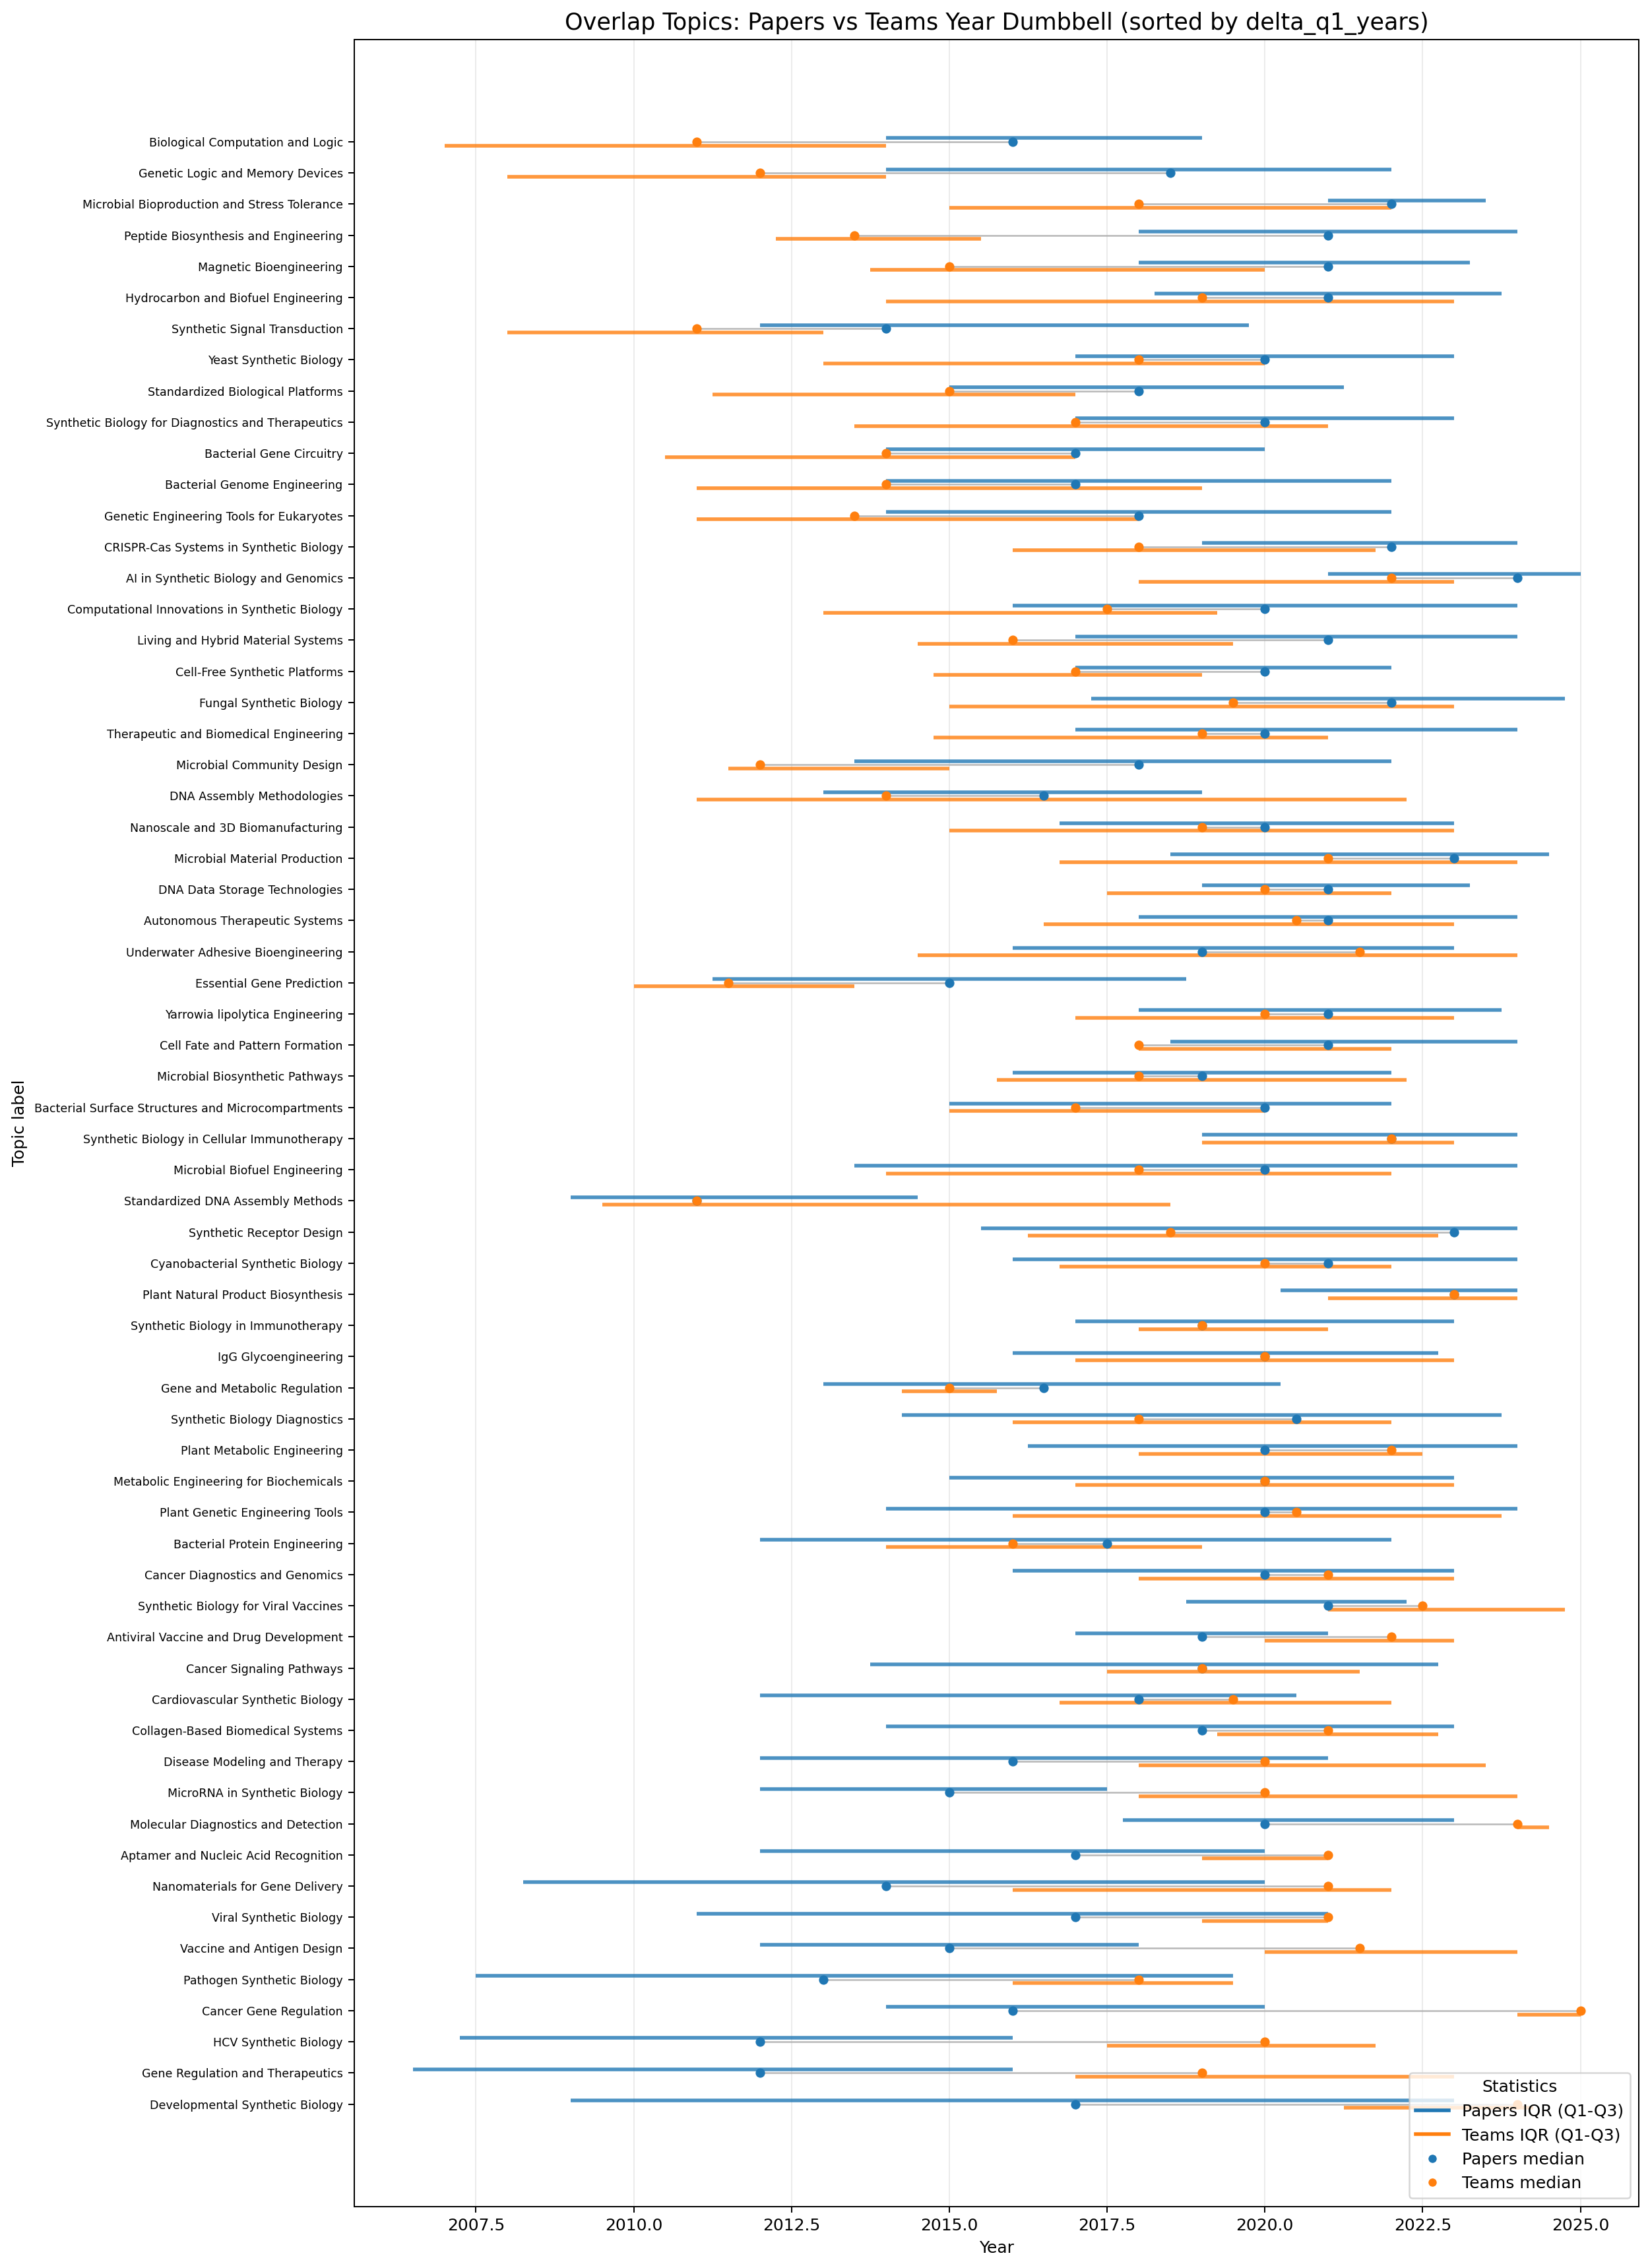

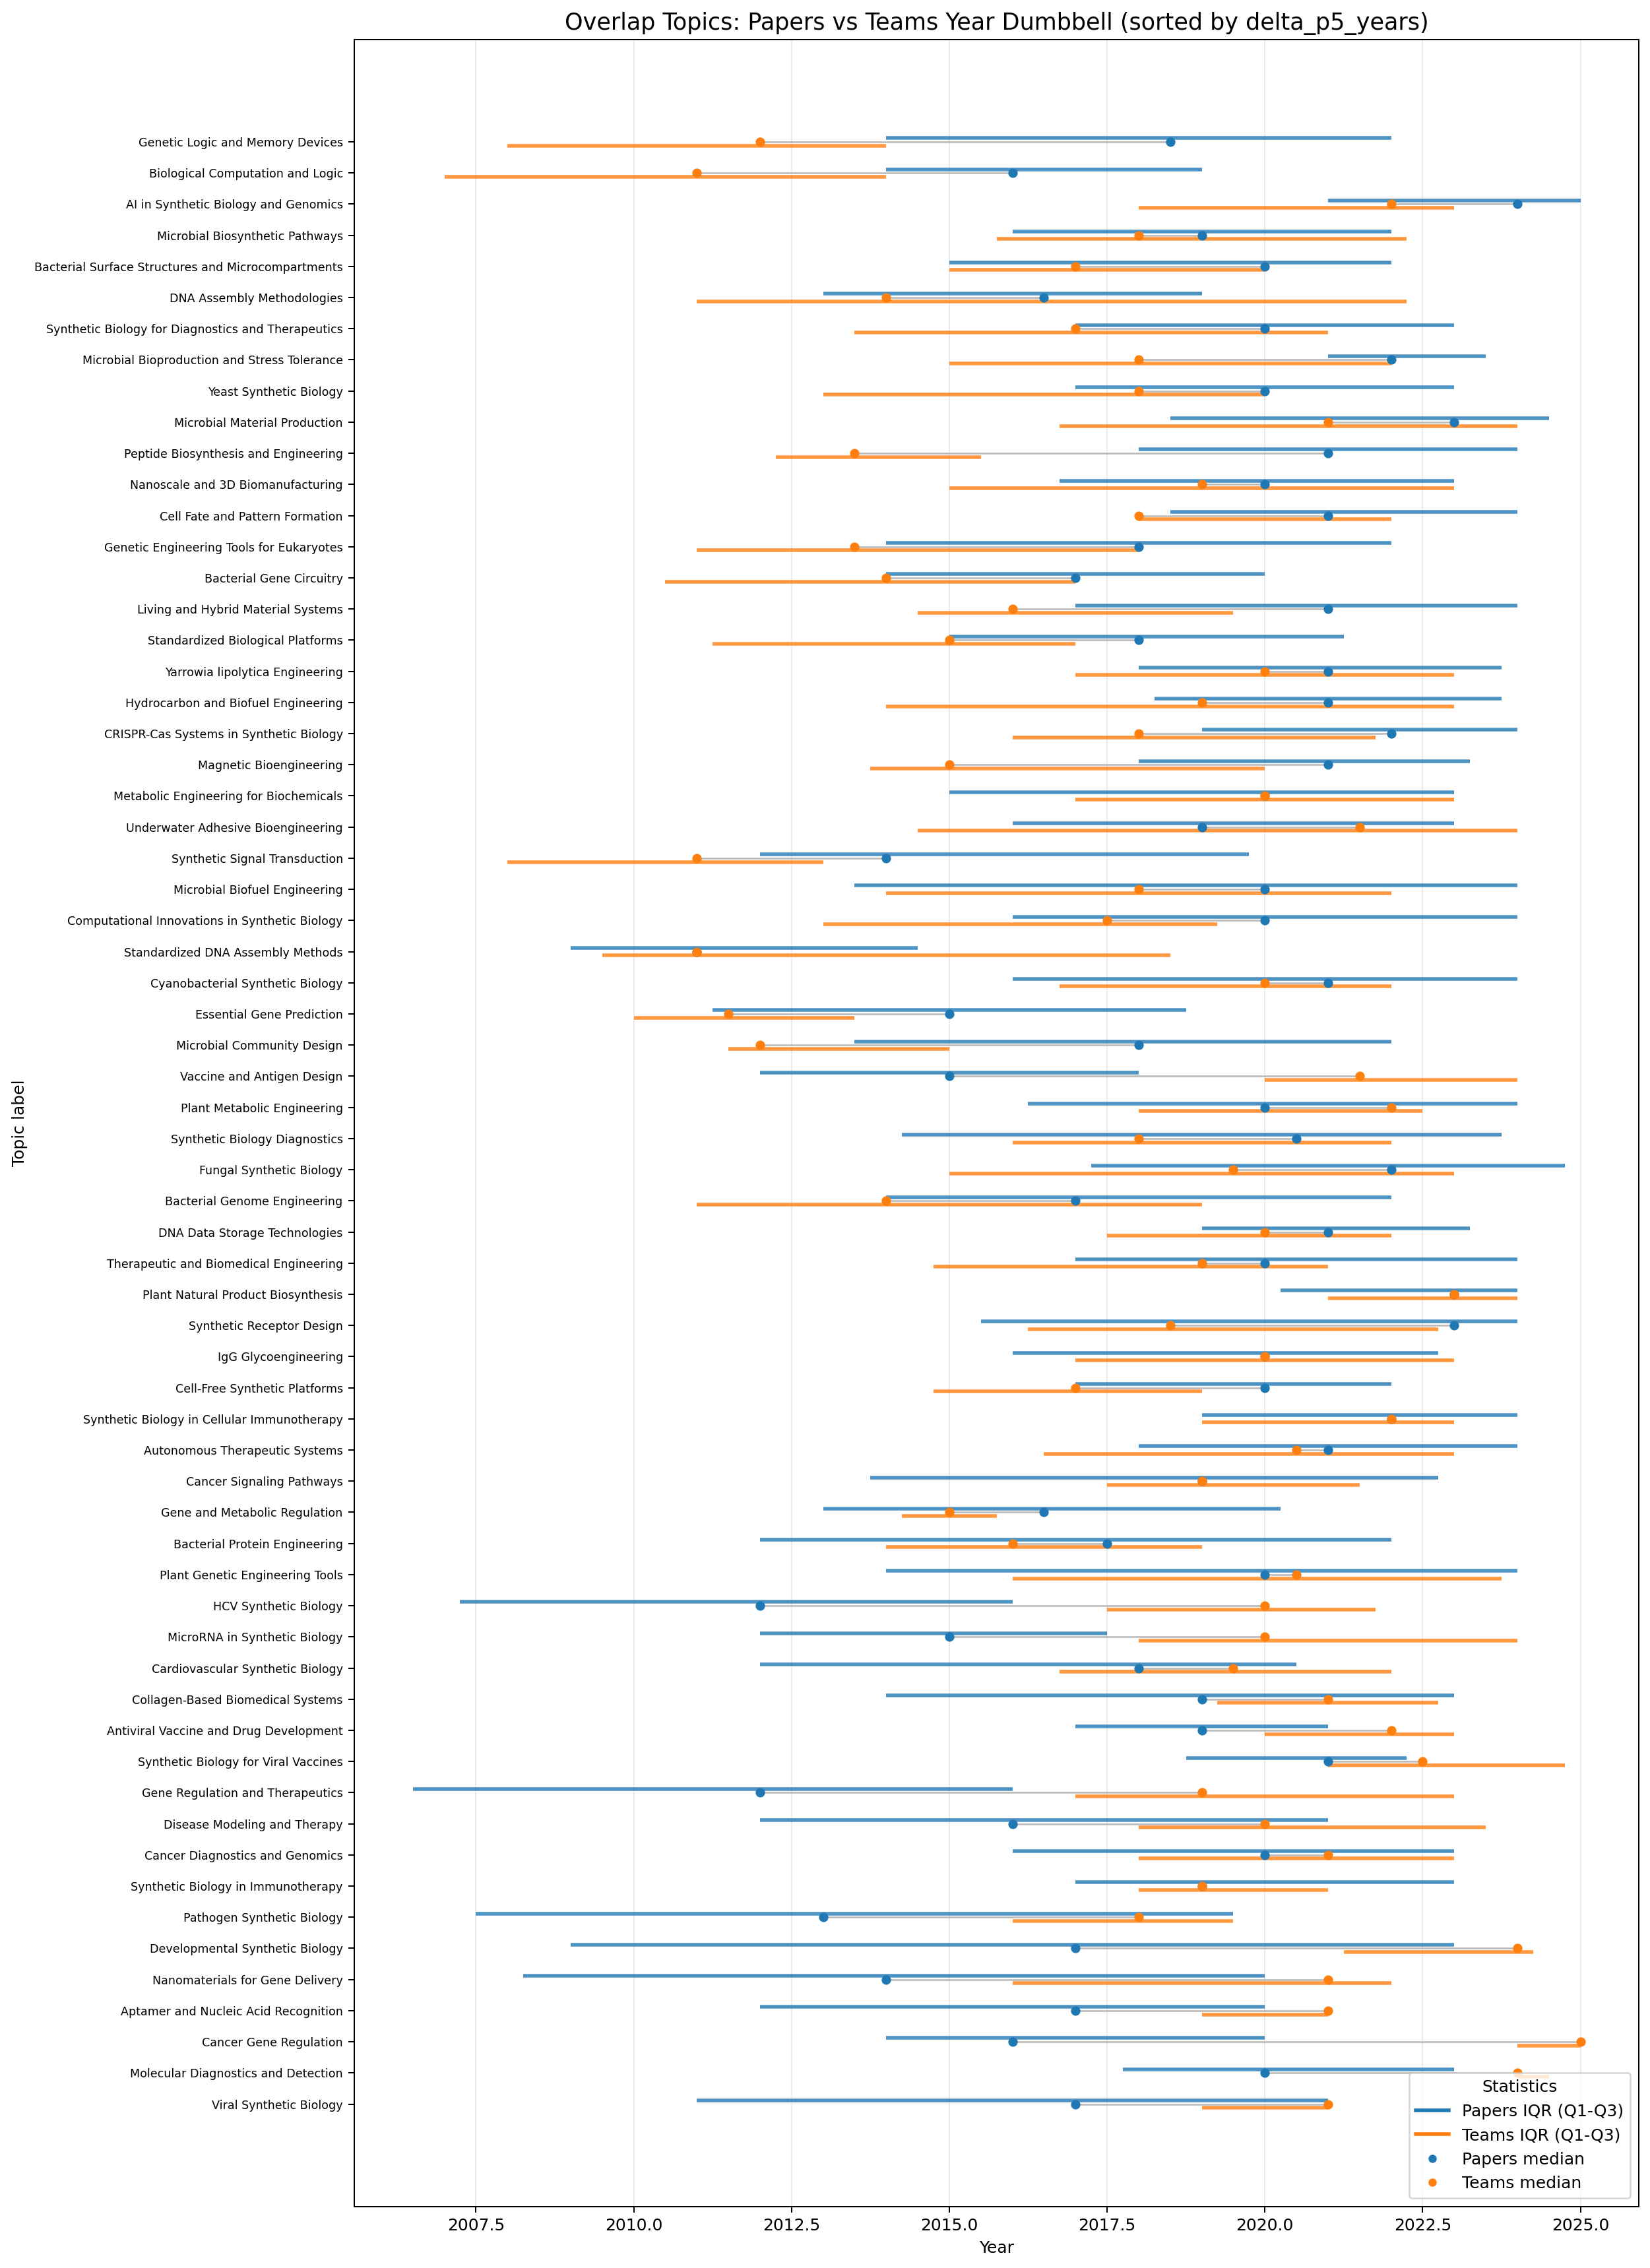

In [15]:
# Option B for both criteria (median + IQR distribution overview, re-sorted per criterion).
for stat, suffix in (("q1", ""), ("p5", "_p5")):
    fig, _ = plot_dumbbell(
        df_prec, stat=stat,
        out_path=REPORTS_DIR / f"overlap_precedence_dumbbell_horizontal{suffix}.png",
    )
    plt.show()

## Option C — diverging precedence gap (centred at zero)

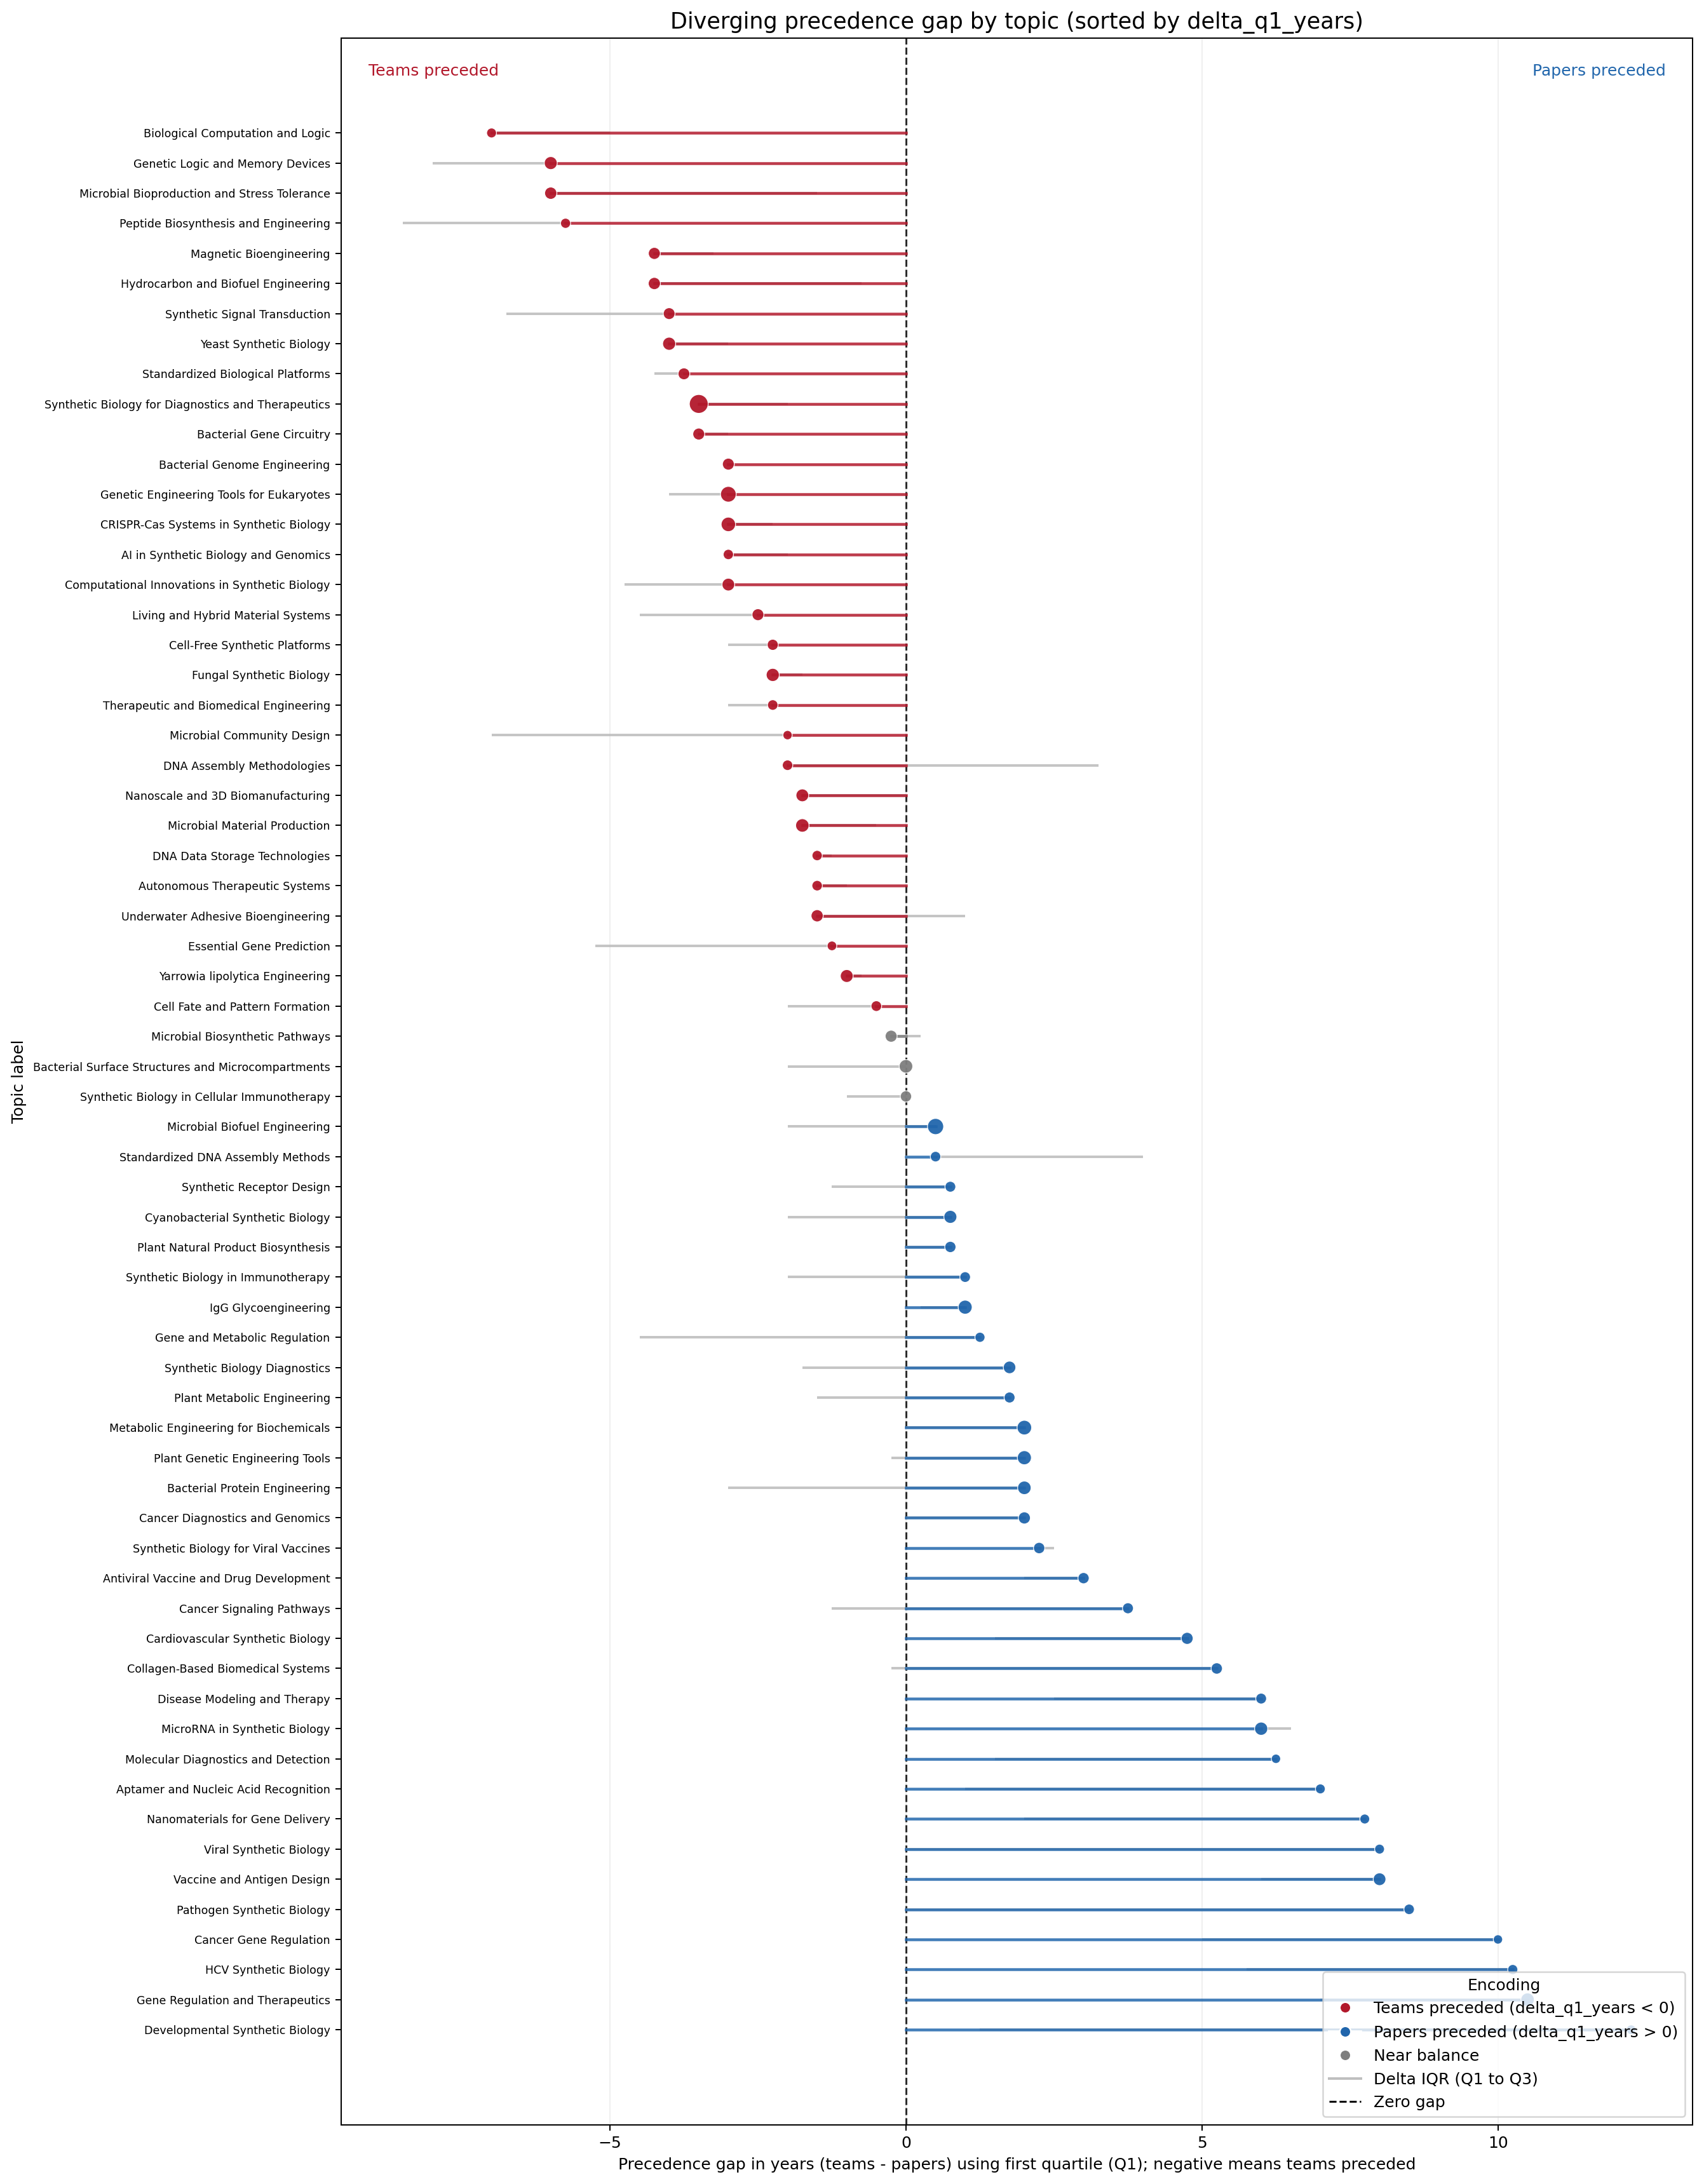

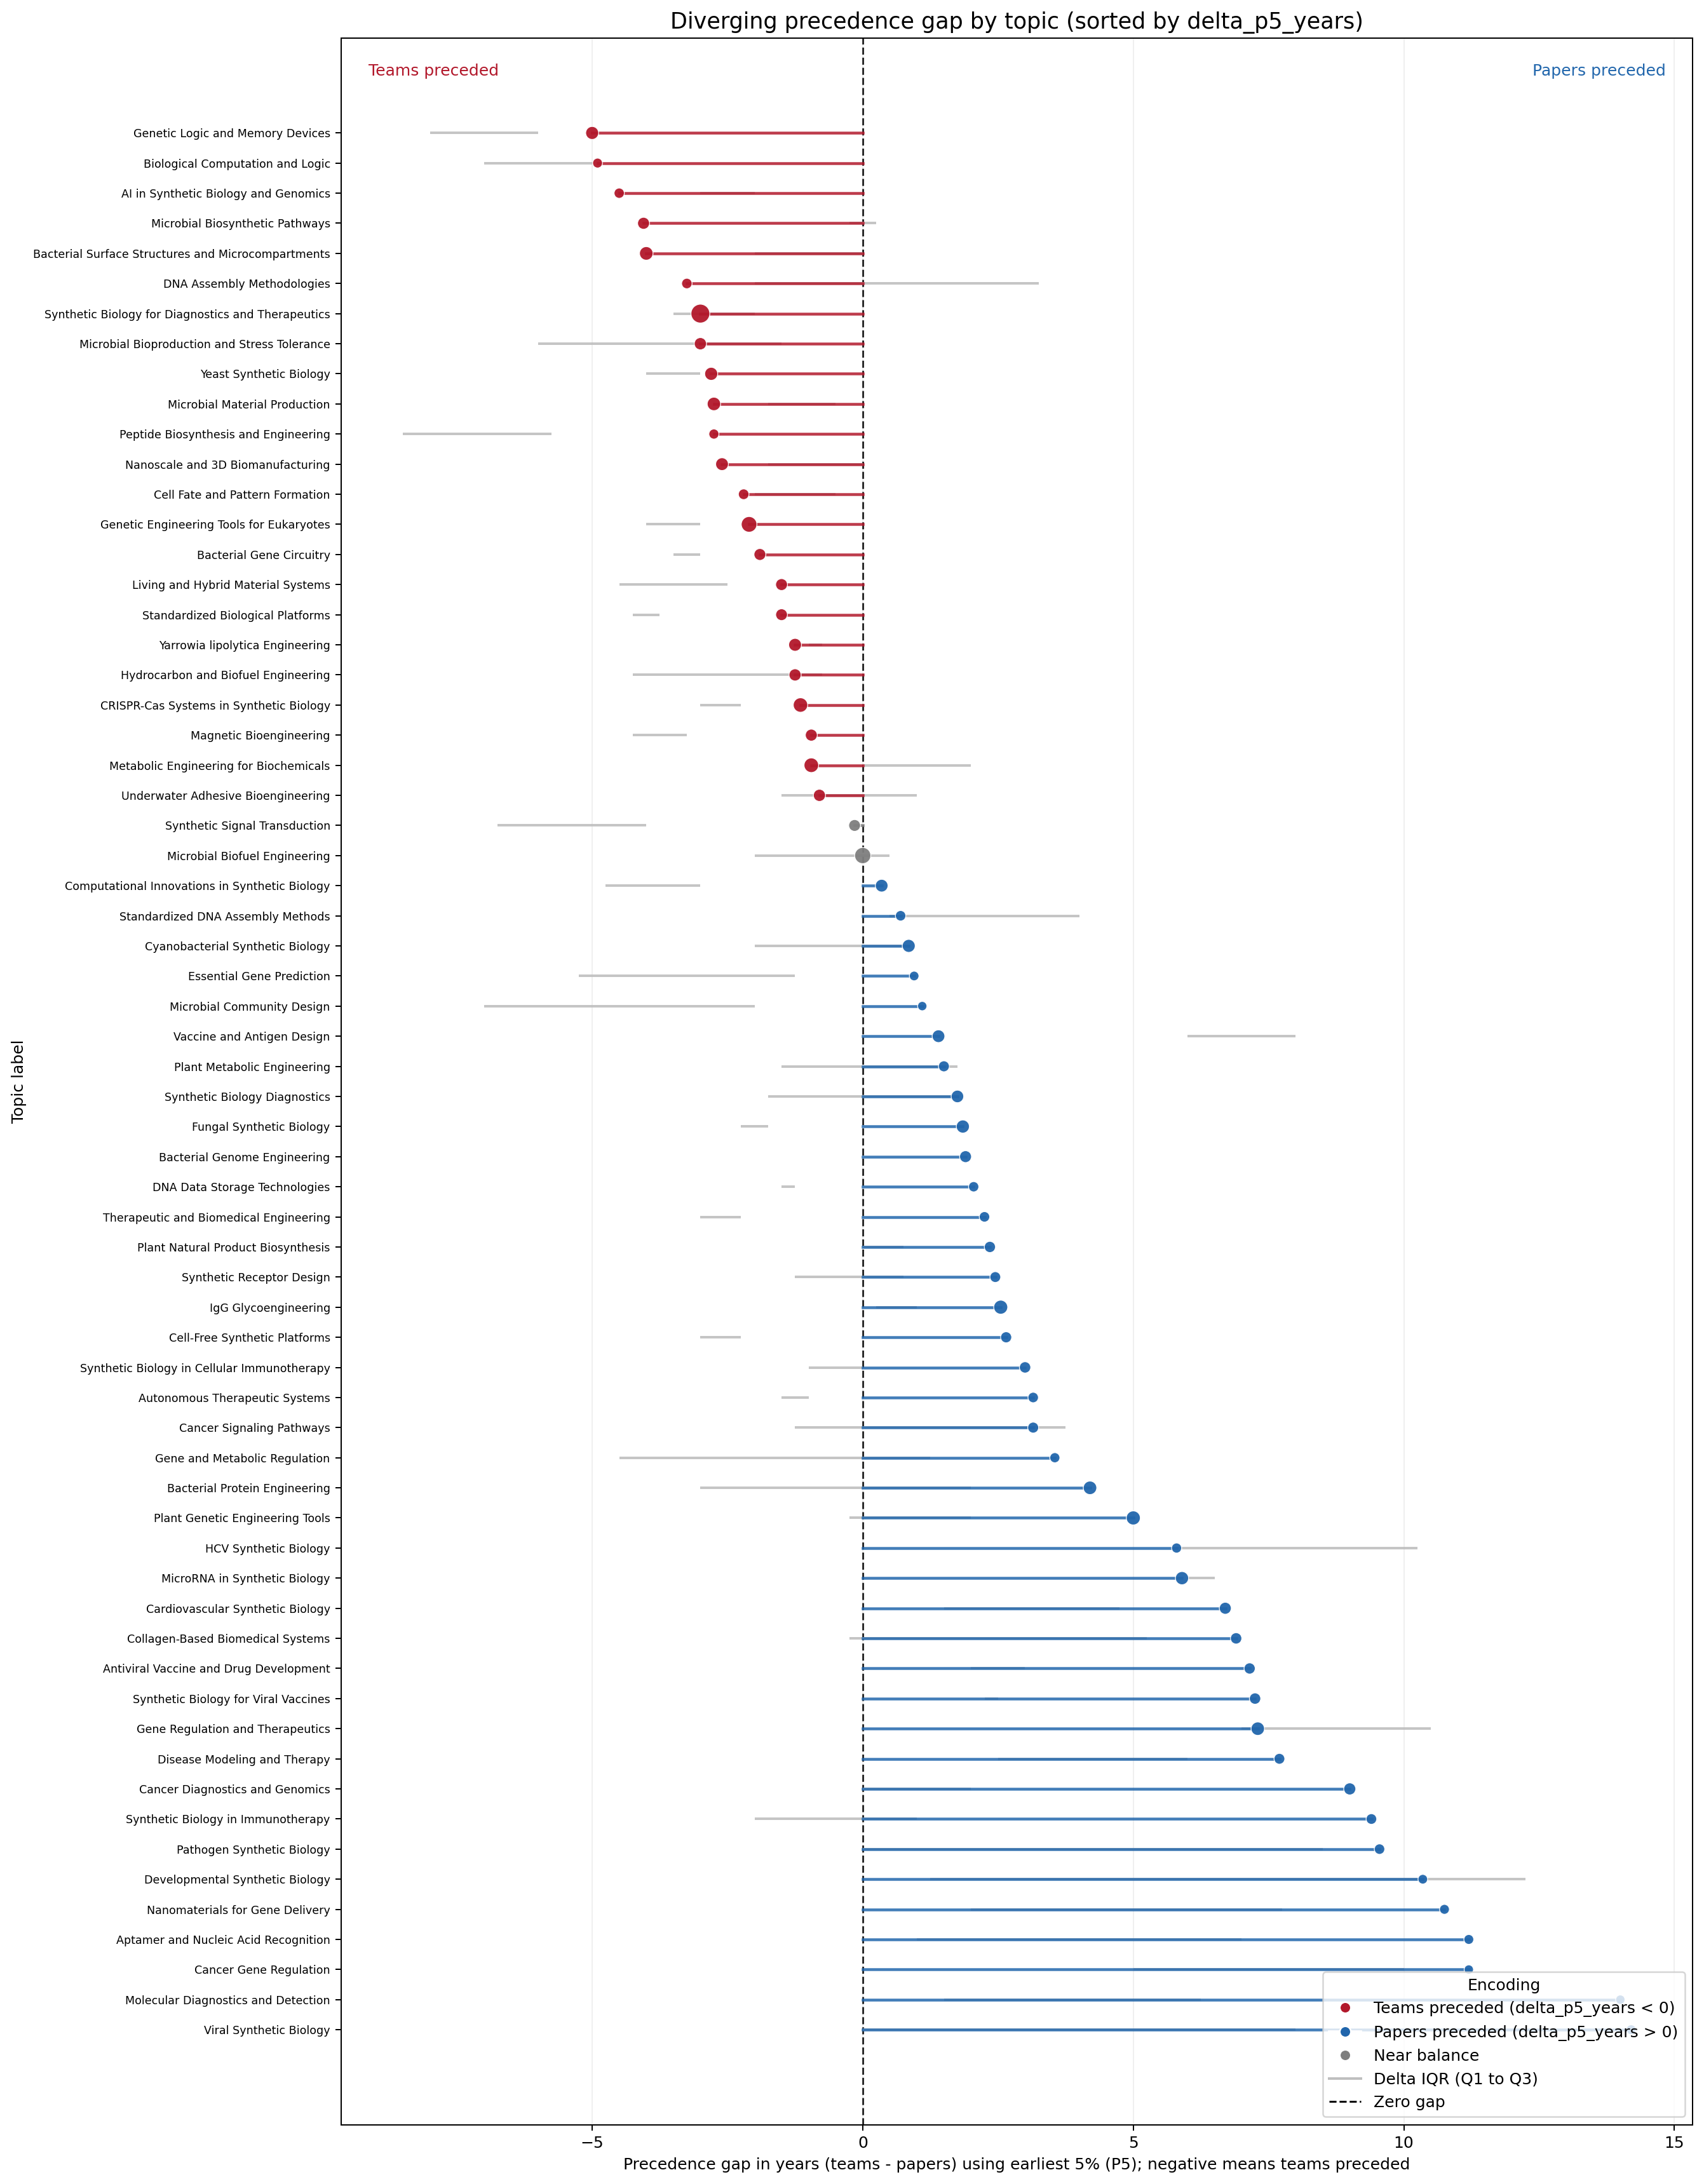

In [16]:
# Option C for both criteria: the gap dot is delta_q1 / delta_p5; grey band stays the delta IQR.
for stat, suffix in (("q1", ""), ("p5", "_p5")):
    fig, _ = plot_diverging(
        df_prec, stat=stat,
        out_path=REPORTS_DIR / f"overlap_precedence_diverging_gap{suffix}.png",
    )
    plt.show()

## Option D — pixel/grid heatmap (analogue of the split violins)

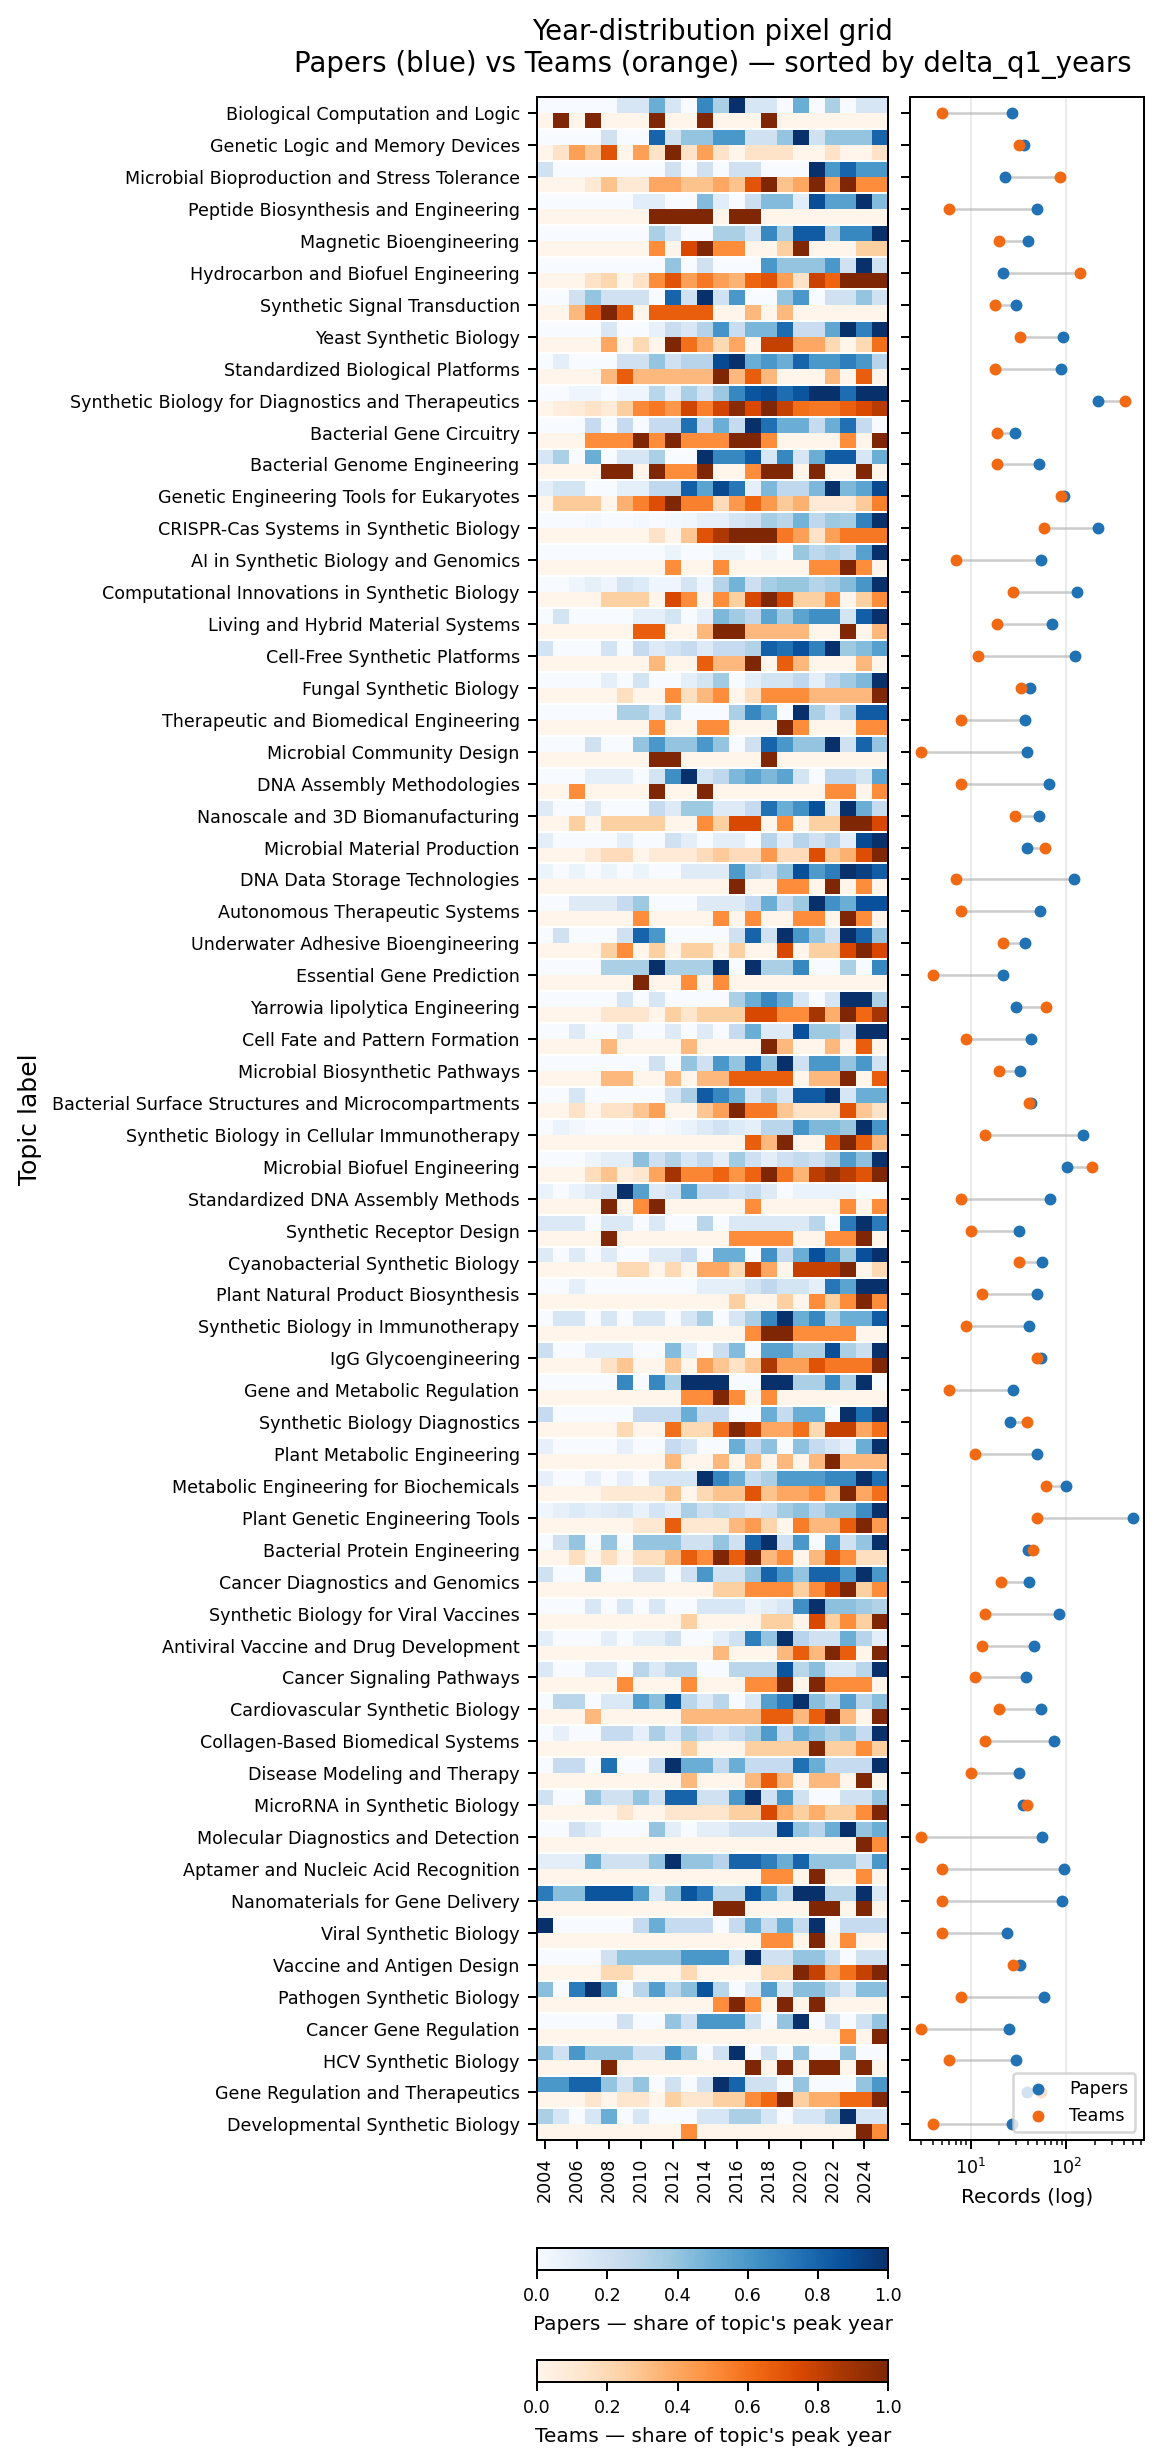

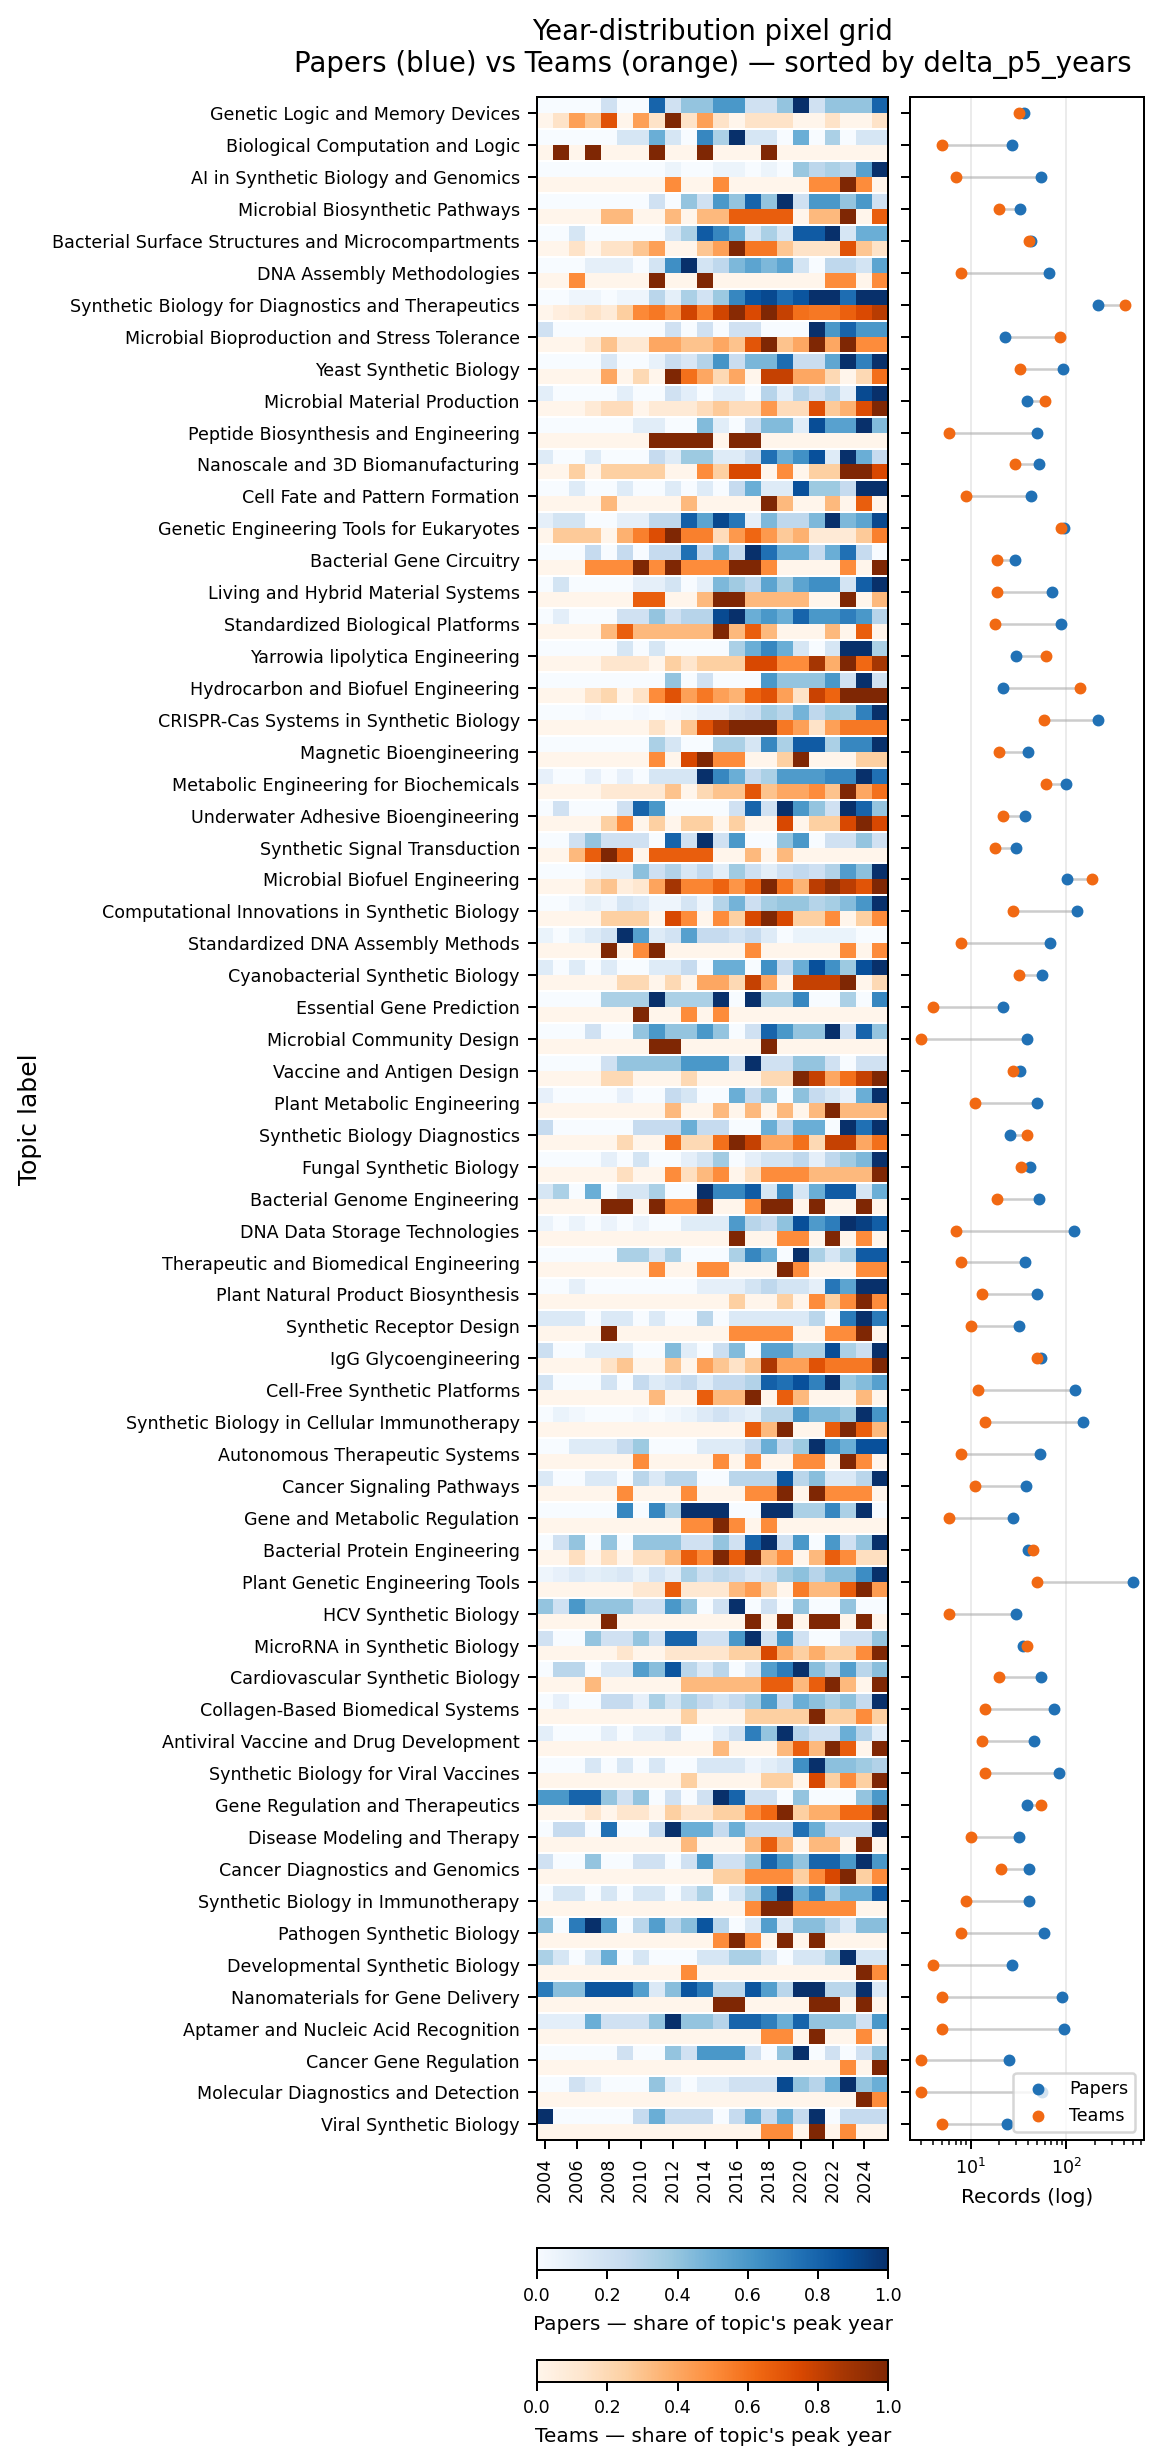

In [17]:
# Option D — 'pixelated' version of the split violins: per topic, two stacked
# year-cell strips (Papers=blue on top, Teams=orange below), each normalised to
# its own peak year. Right panel echoes the reference figure's per-row totals.
for stat, suffix in (("q1", ""), ("p5", "_p5")):
    pool, ordered = gather_year_pools(df_prec, df_papers, df_teams, stat=stat)
    fig, _ = plot_pixel_grid(
        pool, ordered, stat=stat,
        out_path=REPORTS_DIR / f"overlap_precedence_pixel_grid{suffix}.png",
    )
    plt.show()